# model_ver06: PLS / Ridge / SVR ベースライン比較ノートブック

このノートブックでは、`model_ver05` の 1 次元 CNN と比較するために、古典的な回帰モデルのベースラインを作成します。  
CV 設計は `model_ver05` と比較しやすいように、元の `sample number` 単位の GroupKFold に戻しています。

## このノートブックの狙い
- PLS / Ridge / SVR を同じ CV 条件で比較する
- raw スペクトルと SG 後 1 次微分スペクトルのどちらが効くか確認する
- 最良モデルの OOF、test 予測、提出ファイルを保存する

## 出力先
- モデル作成・分析に関与するファイル: `models/`
- 提出用ファイル: `submission/`


## 各関数の役割

- `CFG`  
  パス、CV、SG フィルタ、モデル候補などをまとめて管理します。
- `get_spectral_columns`  
  スペクトル列だけを取り出します。
- `compute_savgol_first_derivative`  
  Savitzky-Golay フィルタで平滑化しながら 1 次微分スペクトルを計算します。
- `build_feature_sets`  
  raw と SG 後 1 次微分の特徴量セットを作成します。
- `make_model_configs`  
  比較する PLS / Ridge / SVR のモデル候補を定義します。
- `run_single_cv`  
  1 つの特徴量セットと 1 つのモデルについて CV、OOF、test 予測を実行します。
- `run_all_baselines`  
  全モデルを比較し、最良モデルの成果物を保存します。


In [19]:
# ============================================================
# ライブラリのインポートと設定値の定義
# ============================================================
import os
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from joblib import dump
from scipy.signal import savgol_filter

from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


class CFG:
    # バージョン名。出力ファイル名にも使う
    VER = 6

    # 乱数 seed
    seed = 42

    # パス設定
    ROOT = Path('/workspace')
    DATA_PATH = ROOT / 'data' / 'raw'
    MODEL_PATH = ROOT / 'models'
    SUBMISSION_PATH = ROOT / 'submission'

    # コンペ設定
    target_col = '含水率'
    group_col = 'sample number'
    drop_cols = ['sample number', 'species number', '樹種', '含水率']
    n_splits = 5

    # Savitzky-Golay フィルタ設定
    sg_window_length = 11
    sg_polyorder = 2

    # PLS は成分数の影響が大きいため、軽く候補を持たせて比較する
    pls_components = [5, 10, 15, 20, 30]
    ridge_alpha = 10.0
    svr_c = 10.0
    svr_epsilon = 0.1
    svr_gamma = 'scale'


CFG.MODEL_PATH.mkdir(parents=True, exist_ok=True)
CFG.SUBMISSION_PATH.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    """乱数 seed をまとめて固定する関数。再現性の確保に使う。"""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


seed_everything(CFG.seed)


In [20]:
# ============================================================
# データの読み込みと特徴量作成
# ============================================================
train_df = pd.read_csv(CFG.DATA_PATH / 'train.csv', encoding='cp932')
test_df = pd.read_csv(CFG.DATA_PATH / 'test.csv', encoding='cp932')
sample_submit_df = pd.read_csv(CFG.DATA_PATH / 'sample_submit.csv', header=None, encoding='cp932')


def get_spectral_columns(df: pd.DataFrame) -> List[str]:
    """目的変数や ID 列を除外し、スペクトル列だけを返す関数。"""
    return [col for col in df.columns if col not in CFG.drop_cols]


def rmse_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """RMSE を計算する関数。コンペの評価指標に合わせる。"""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def validate_savgol_params(window_length: int, polyorder: int, signal_length: int) -> None:
    """Savitzky-Golay フィルタの設定が妥当か事前に確認する関数。"""
    if window_length % 2 == 0:
        raise ValueError('sg_window_length は奇数である必要があります。')
    if window_length <= polyorder:
        raise ValueError('sg_window_length は sg_polyorder より大きい必要があります。')
    if window_length > signal_length:
        raise ValueError('sg_window_length はスペクトル長以下である必要があります。')


def compute_savgol_first_derivative(
    x: np.ndarray,
    delta: float,
    window_length: int,
    polyorder: int,
) -> np.ndarray:
    """SG フィルタで平滑化しながら 1 次微分スペクトルを計算する関数。"""
    derivative = savgol_filter(
        x,
        window_length=window_length,
        polyorder=polyorder,
        deriv=1,
        delta=delta,
        axis=1,
        mode='interp',
    )
    return derivative.astype(np.float32)


def build_feature_sets(
    raw_train: np.ndarray,
    raw_test: np.ndarray,
    wave_numbers: np.ndarray,
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    """比較しやすいように、特徴量セットを辞書でまとめて返す関数。"""
    signal_length = raw_train.shape[1]
    validate_savgol_params(CFG.sg_window_length, CFG.sg_polyorder, signal_length)

    # 波数列は降順なので、間隔の絶対値を使う
    delta = float(np.mean(np.abs(np.diff(wave_numbers))))
    train_derivative = compute_savgol_first_derivative(
        raw_train,
        delta=delta,
        window_length=CFG.sg_window_length,
        polyorder=CFG.sg_polyorder,
    )
    test_derivative = compute_savgol_first_derivative(
        raw_test,
        delta=delta,
        window_length=CFG.sg_window_length,
        polyorder=CFG.sg_polyorder,
    )

    train_features = {
        'raw': raw_train,
        'sg_1deriv': train_derivative,
    }
    test_features = {
        'raw': raw_test,
        'sg_1deriv': test_derivative,
    }
    return train_features, test_features


spectral_cols = get_spectral_columns(train_df)
wave_numbers = np.array([float(col) for col in spectral_cols], dtype=np.float32)
raw_train = train_df[spectral_cols].values.astype(np.float32)
raw_test = test_df[spectral_cols].values.astype(np.float32)
y_train = train_df[CFG.target_col].values.astype(np.float32)
groups = train_df[CFG.group_col].values

n_groups = pd.Series(groups).nunique()
if CFG.n_splits > n_groups:
    raise ValueError(f'n_splits={CFG.n_splits} は group 数={n_groups} 以下にしてください。')

train_feature_sets, test_feature_sets = build_feature_sets(raw_train, raw_test, wave_numbers)

print(f'train shape: {train_df.shape}')
print(f'test shape: {test_df.shape}')
print(f'スペクトル列数: {len(spectral_cols)}')
print(f'CV group column: {CFG.group_col}')
print(f'CV group 数: {n_groups}')
print(f'特徴量セット: {list(train_feature_sets.keys())}')


train shape: (1322, 1559)
test shape: (550, 1558)
スペクトル列数: 1555
CV group column: sample number
CV group 数: 1322
特徴量セット: ['raw', 'sg_1deriv']


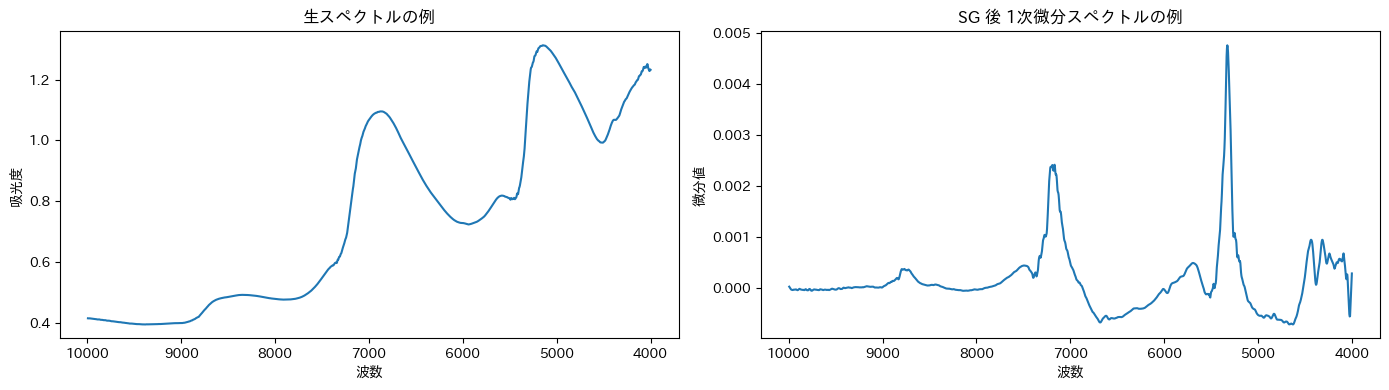

In [21]:
# ============================================================
# 特徴量の見た目確認
# ============================================================
example_idx = 0

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(wave_numbers, train_feature_sets['raw'][example_idx])
plt.gca().invert_xaxis()
plt.title('生スペクトルの例')
plt.xlabel('波数')
plt.ylabel('吸光度')

plt.subplot(1, 2, 2)
plt.plot(wave_numbers, train_feature_sets['sg_1deriv'][example_idx])
plt.gca().invert_xaxis()
plt.title('SG 後 1次微分スペクトルの例')
plt.xlabel('波数')
plt.ylabel('微分値')

plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# モデル定義と CV 実行関数
# ============================================================
def make_model_configs(signal_length: int) -> List[Tuple[str, Pipeline]]:
    """比較する PLS / Ridge / SVR の候補を定義する関数。"""
    model_configs = []

    for n_components in CFG.pls_components:
        if n_components > signal_length:
            continue
        model_configs.append(
            (
                f'pls_{n_components}',
                Pipeline(
                    steps=[
                        ('scaler', StandardScaler()),
                        ('model', PLSRegression(n_components=n_components, scale=False)),
                    ]
                ),
            )
        )

    model_configs.extend(
        [
            (
                'ridge',
                Pipeline(
                    steps=[
                        ('scaler', StandardScaler()),
                        ('model', Ridge(alpha=CFG.ridge_alpha, random_state=CFG.seed)),
                    ]
                ),
            ),
            (
                'svr',
                Pipeline(
                    steps=[
                        ('scaler', StandardScaler()),
                        (
                            'model',
                            SVR(
                                C=CFG.svr_c,
                                epsilon=CFG.svr_epsilon,
                                gamma=CFG.svr_gamma,
                            ),
                        ),
                    ]
                ),
            ),
        ]
    )
    return model_configs


def run_single_cv(
    x: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    x_test: np.ndarray,
    feature_name: str,
    model_name: str,
    base_model: Pipeline,
) -> Tuple[dict, np.ndarray, np.ndarray, list]:
    """1 つの特徴量セットとモデルについて CV と test 予測を実行する関数。"""
    splitter = GroupKFold(n_splits=CFG.n_splits)

    oof_preds = np.zeros(len(x), dtype=np.float32)
    test_preds = np.zeros(len(x_test), dtype=np.float32)
    fold_scores = []
    fold_models = []

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(x, y, groups), start=1):
        model = clone(base_model)
        model.fit(x[train_idx], y[train_idx])

        valid_preds = model.predict(x[valid_idx]).reshape(-1)
        fold_test_preds = model.predict(x_test).reshape(-1)

        oof_preds[valid_idx] = valid_preds
        test_preds += fold_test_preds / CFG.n_splits

        fold_rmse = rmse_score(y[valid_idx], valid_preds)
        fold_scores.append(fold_rmse)
        fold_models.append(model)

        print(
            f'{feature_name:9s} | {model_name:8s} | '
            f'fold {fold} RMSE: {fold_rmse:.4f}'
        )

    cv_rmse = rmse_score(y, oof_preds)
    result = {
        'feature': feature_name,
        'model': model_name,
        'cv_rmse': cv_rmse,
        'fold_rmse_mean': float(np.mean(fold_scores)),
        'fold_rmse_std': float(np.std(fold_scores)),
    }
    return result, oof_preds, test_preds, fold_models


In [23]:
# ============================================================
# 全ベースラインの比較と保存
# ============================================================
def save_submission(predictions: np.ndarray, save_name: str) -> Path:
    """サンプル提出ファイルの形式で予測値を書き出す関数。"""
    submit_df = sample_submit_df.copy()
    submit_df[1] = predictions
    save_path = CFG.SUBMISSION_PATH / save_name
    submit_df.to_csv(save_path, header=False, index=False)
    return save_path


def run_all_baselines() -> Tuple[pd.DataFrame, dict]:
    """特徴量セットとモデル候補を総当たりで比較し、最良結果を保存する関数。"""
    results = []
    best = {
        'cv_rmse': np.inf,
        'feature': None,
        'model': None,
        'oof_preds': None,
        'test_preds': None,
        'fold_models': None,
    }

    for feature_name, x in train_feature_sets.items():
        x_test = test_feature_sets[feature_name]
        model_configs = make_model_configs(signal_length=x.shape[1])

        for model_name, base_model in model_configs:
            print('=' * 70)
            result, oof_preds, test_preds, fold_models = run_single_cv(
                x=x,
                y=y_train,
                groups=groups,
                x_test=x_test,
                feature_name=feature_name,
                model_name=model_name,
                base_model=base_model,
            )
            results.append(result)
            print(f"CV RMSE: {result['cv_rmse']:.4f}")

            if result['cv_rmse'] < best['cv_rmse']:
                best.update(
                    {
                        'cv_rmse': result['cv_rmse'],
                        'feature': feature_name,
                        'model': model_name,
                        'oof_preds': oof_preds,
                        'test_preds': test_preds,
                        'fold_models': fold_models,
                    }
                )

    results_df = pd.DataFrame(results).sort_values('cv_rmse').reset_index(drop=True)
    results_df.to_csv(CFG.MODEL_PATH / 'model_ver06_cv_results.csv', index=False, encoding='utf-8-sig')

    best_name = f"{best['feature']}_{best['model']}"

    oof_df = train_df[['sample number', 'species number', '樹種', '含水率']].copy()
    oof_df['oof_pred'] = best['oof_preds']
    oof_df.to_csv(CFG.MODEL_PATH / f'model_ver06_oof_{best_name}.csv', index=False, encoding='utf-8-sig')

    pred_df = test_df[['sample number', 'species number', '樹種']].copy()
    pred_df['pred'] = best['test_preds']
    pred_df.to_csv(CFG.MODEL_PATH / f'model_ver06_test_pred_{best_name}.csv', index=False, encoding='utf-8-sig')

    dump(best['fold_models'], CFG.MODEL_PATH / f'model_ver06_fold_models_{best_name}.joblib')
    submission_path = save_submission(best['test_preds'], 'model_ver06_submission.csv')

    print('=' * 70)
    print(f"Best feature: {best['feature']}")
    print(f"Best model: {best['model']}")
    print(f"Best CV RMSE: {best['cv_rmse']:.4f}")
    print(f'提出ファイル保存先: {submission_path}')

    return results_df, best


results_df, best_result = run_all_baselines()
display(results_df)


raw       | pls_5    | fold 1 RMSE: 22.8160
raw       | pls_5    | fold 2 RMSE: 21.6100
raw       | pls_5    | fold 3 RMSE: 22.7907
raw       | pls_5    | fold 4 RMSE: 22.3053
raw       | pls_5    | fold 5 RMSE: 22.6498
CV RMSE: 22.4385
raw       | pls_10   | fold 1 RMSE: 17.4636
raw       | pls_10   | fold 2 RMSE: 17.5362
raw       | pls_10   | fold 3 RMSE: 17.8303
raw       | pls_10   | fold 4 RMSE: 17.8526
raw       | pls_10   | fold 5 RMSE: 17.9657
CV RMSE: 17.7304
raw       | pls_15   | fold 1 RMSE: 14.4993
raw       | pls_15   | fold 2 RMSE: 15.6433
raw       | pls_15   | fold 3 RMSE: 14.3866
raw       | pls_15   | fold 4 RMSE: 15.0286
raw       | pls_15   | fold 5 RMSE: 14.9243
CV RMSE: 14.9034
raw       | pls_20   | fold 1 RMSE: 12.1865
raw       | pls_20   | fold 2 RMSE: 13.5331
raw       | pls_20   | fold 3 RMSE: 12.3375
raw       | pls_20   | fold 4 RMSE: 12.1710
raw       | pls_20   | fold 5 RMSE: 13.1350
CV RMSE: 12.6852
raw       | pls_30   | fold 1 RMSE: 10.7663
raw     

,feature,model,cv_rmse,fold_rmse_mean,fold_rmse_std
0,sg_1deriv,ridge,10.271417,10.259934,0.490611
1,sg_1deriv,pls_20,10.803033,10.789193,0.555922
2,sg_1deriv,pls_30,10.818286,10.806138,0.507510
3,sg_1deriv,pls_15,11.486969,11.475898,0.512530
4,raw,pls_30,12.547662,12.306679,2.459648
5,raw,pls_20,12.685153,12.672599,0.557575
6,raw,pls_15,14.903373,14.896432,0.445813
7,sg_1deriv,pls_10,15.023156,15.013620,0.546997
8,sg_1deriv,svr,15.451542,15.442219,0.563368
9,raw,ridge,17.124584,17.123947,0.176855


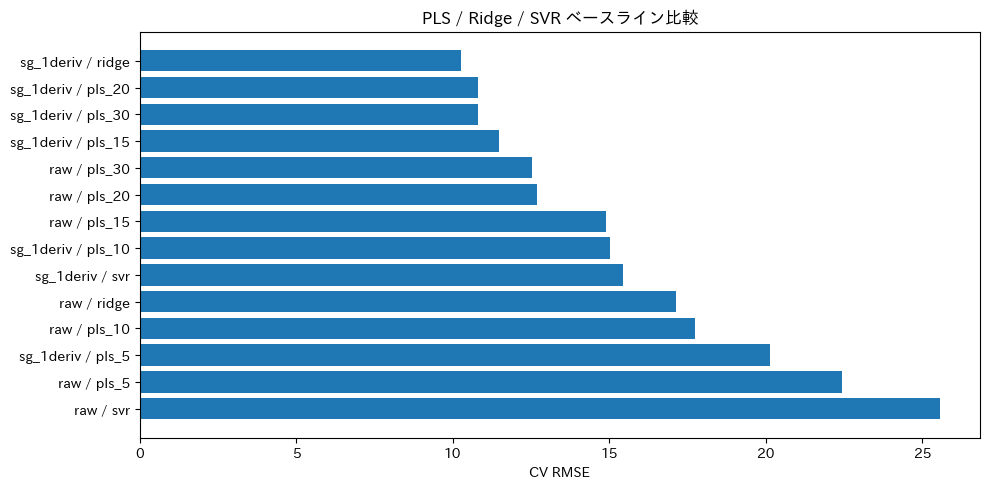

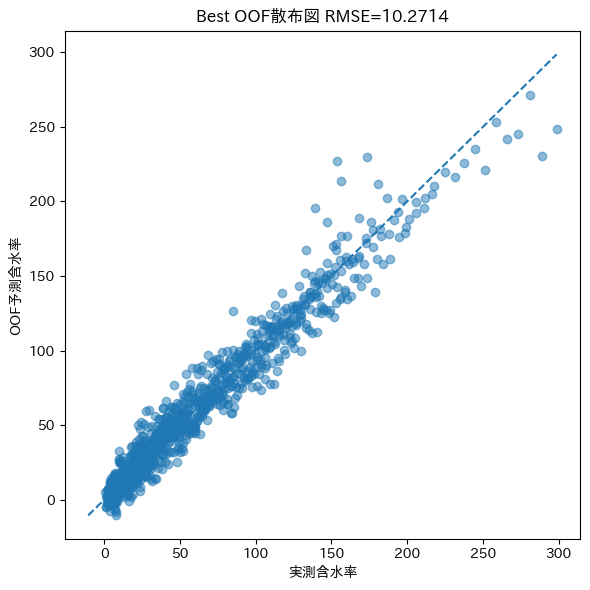

In [24]:
# ============================================================
# 学習結果の可視化
# ============================================================
plt.figure(figsize=(10, 5))
plot_df = results_df.sort_values('cv_rmse', ascending=True).copy()
plot_df['label'] = plot_df['feature'] + ' / ' + plot_df['model']
plt.barh(plot_df['label'], plot_df['cv_rmse'])
plt.gca().invert_yaxis()
plt.xlabel('CV RMSE')
plt.title('PLS / Ridge / SVR ベースライン比較')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_train, best_result['oof_preds'], alpha=0.5)
line_min = min(y_train.min(), best_result['oof_preds'].min())
line_max = max(y_train.max(), best_result['oof_preds'].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.xlabel('実測含水率')
plt.ylabel('OOF予測含水率')
plt.title(f"Best OOF散布図 RMSE={best_result['cv_rmse']:.4f}")
plt.tight_layout()
plt.show()


## 補足

- `model_ver06` は CNN ではなく、PLS / Ridge / SVR の比較用ベースラインです。
- CV は `sample number` 単位の GroupKFold に戻しています。
- `raw` と `sg_1deriv` を同じモデル候補で比較し、最良モデルの OOF / test 予測 / fold モデルを保存します。
- 次に発展させるなら、SNV、SG 2 次微分、PLS 成分数の追加探索、Ridge / SVR のパラメータ調整が比較しやすいです。
